# Feature Extraction notebook
we are continuing the EDA process with the feature extraction of the Data we made in the first notebook. In the first notebook we created the CSV and metadata table. Before the start of this notebook I made a featureextraction.py that goes through and gets all of the features outlined in github. There was MFCC, MFCC delta, MFCC delta 2, Chroma, Mel spectogram, RMS, Centroid, Bandwidth, ZCR, and rolloff. For each feature we have the mean, std, min, and max

In [8]:
#Imports
from pathlib import Path   
import pandas as pd
import matplotlib.pyplot as plt
import os
import seaborn as sns
# Audio
import librosa
import librosa.display

# Always run from SER_Project/ regardless of where the notebook lives
if Path.cwd().name == "notebooks":
    os.chdir("..")

print("Working dir:", os.getcwd())

Working dir: c:\Users\bradd\Project_CSE432-532\SER_Project


Now that we have everything setup in the imports, our first job will be to run the build_feature_table method which utilized our metadata.csv. It will create a dataframe of all of the features and then also create a .csv at our /data/processed/features.csv

In [3]:
from minilearn.featureextraction import build_feature_table

# Comment this line out after the first run so you don't re-extract every
# time you restart the kernel
features = build_feature_table()

Loaded metadata with 2452 rows


Extracting features:   0%|          | 0/2452 [00:00<?, ?it/s]c:\Users\bradd\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Extracting features:  85%|████████▍ | 2080/2452 [02:16<00:25, 14.83it/s]c:\Users\bradd\Project_CSE432-532\SER_Project\minilearn\featureextraction.py:17: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(str(wav_path), sr=SAMPLE_RATE)
c:\Users\bradd\AppData\Local\Programs\Python\Python313\Lib\site-packages\librosa\core\audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
Extracting features:  85%|████████▍ | 2083/2452 [02:16<00:21, 17.33it/s]

Skipping bad file


Extracting features: 100%|██████████| 2452/2452 [02:40<00:00, 15.24it/s]



Saved features to: data/processed/features.csv
Shape: (2451, 496)


As you can see after we run it, we get all of our original data points minus one. The shape gives us 2451 rows followed by 496 columns with 480 of those being different features. below lets just make sure again that everything is setup as we want it.

In [5]:
print(features.shape)
features.head()

(2451, 496)


,filename,filepath,modality_number,modality,vocal_channel_number,vocal_channel,emotion_code,emotion,intensity_number,intensity,...,spec_centroid_min,spec_centroid_max,spec_bandwidth_mean,spec_bandwidth_std,spec_bandwidth_min,spec_bandwidth_max,spec_rolloff_mean,spec_rolloff_std,spec_rolloff_min,spec_rolloff_max
0,03-01-01-01-01-01-01.wav,data\Actor_01\03-01-01-01-01-01-01.wav,3,audio-only,1,speech,1,neutral,1,normal,...,0.000000,14584.465982,5551.291828,1966.670942,0.000000,7941.362325,13285.735887,7873.634242,0.0000,20929.6875
1,03-01-01-01-01-02-01.wav,data\Actor_01\03-01-01-01-01-02-01.wav,3,audio-only,1,speech,1,neutral,1,normal,...,850.770544,12081.525541,5653.771579,1897.506371,2300.580933,8065.492390,13191.643371,7634.107567,960.9375,21140.6250
2,03-01-01-01-02-01-01.wav,data\Actor_01\03-01-01-01-02-01-01.wav,3,audio-only,1,speech,1,neutral,1,normal,...,0.000000,12170.914340,5641.048020,2054.943735,0.000000,7938.570208,13279.137826,7981.393363,0.0000,21140.6250
3,03-01-01-01-02-02-01.wav,data\Actor_01\03-01-01-01-02-02-01.wav,3,audio-only,1,speech,1,neutral,1,normal,...,1001.254209,12108.222580,5802.315322,1915.796134,2313.602810,7918.679500,13272.074245,7570.671093,937.5000,21187.5000
4,03-01-02-01-01-01-01.wav,data\Actor_01\03-01-02-01-01-01-01.wav,3,audio-only,1,speech,2,calm,1,normal,...,0.000000,13533.883723,5518.637359,1916.039762,0.000000,8027.820710,12649.543486,7902.073642,0.0000,21585.9375


Now that we have the entire new dataframe loaded with the features it is time to go and do the analysis that you have put on github. Those being the correlation analysis, feature distribution by emotion, and visualizations. I will go one by one in the cells below

The first thing we are going to do below is feature distribution by emotion. A lot of the different features looked almost un-interaple by just looking at it. These four have been cherry picked because they are easy to see the differences between different emotions.

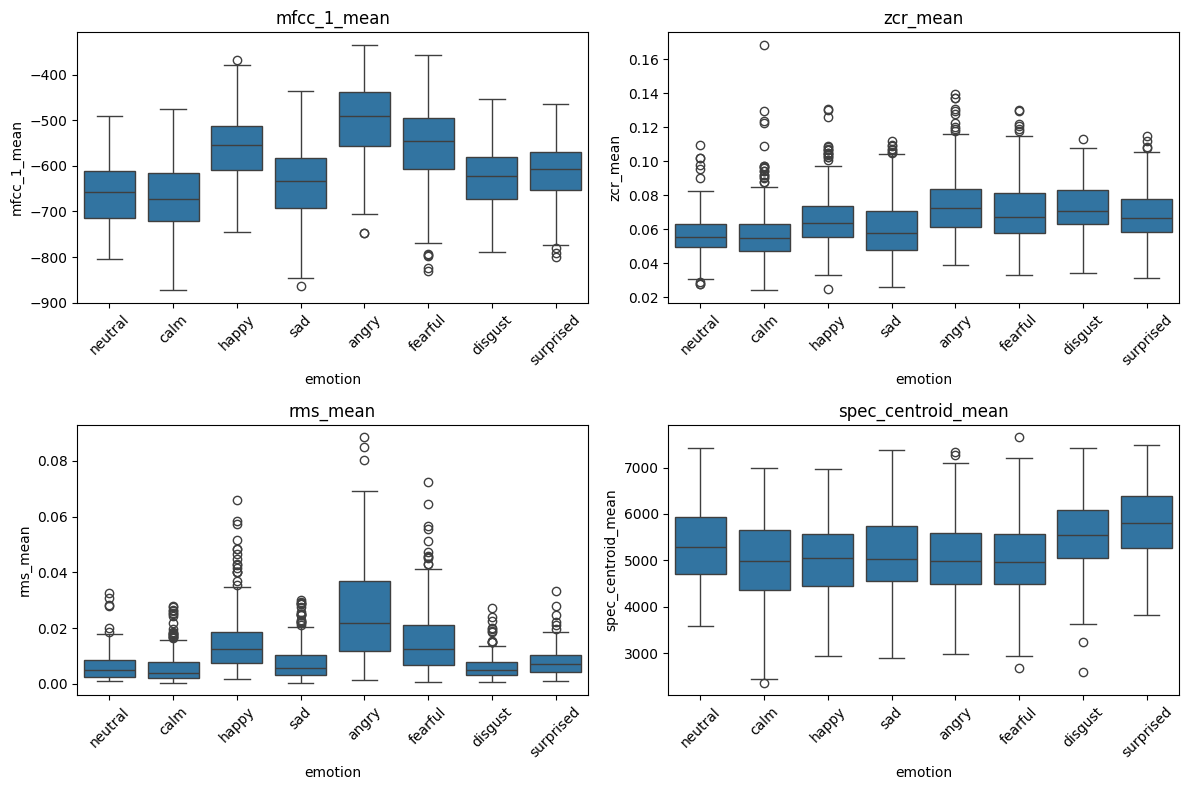

In [9]:
features_to_plot = ["mfcc_1_mean", "zcr_mean", "rms_mean", "spec_centroid_mean"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, feat in zip(axes.flat, features_to_plot):
    sns.boxplot(data=features, x="emotion", y=feat, ax=ax)
    ax.set_title(feat)
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()